In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.inspection import permutation_importance
import shap
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set up paths
DATA_FEATURES_PATH = "../data/processed/features/"

# Load engineered features
train_data = pd.read_parquet(f"{DATA_FEATURES_PATH}train_features_fully_engineered.parquet")
test_data = pd.read_parquet(f"{DATA_FEATURES_PATH}test_features_fully_engineered.parquet")

print(f"Train shape: {train_data.shape}")
print(f"Test shape: {test_data.shape}")
print(f"Fraud rate: {train_data['isFraud'].mean():.4f}")

Train shape: (590540, 269)
Test shape: (506691, 268)
Fraud rate: 0.0350


In [14]:
# Prepare features and target
X = train_data.drop(columns=['TransactionID', 'isFraud'])
y = train_data['isFraud']
test_ids = test_data['TransactionID']
X_test = test_data.drop(columns=['TransactionID'])

print(f"Features for selection: {X.shape[1]}")

Features for selection: 267


## 1. Enhanced Multi-Method Feature Importance


In [4]:
def enhanced_feature_selection(X, y, top_k=100, random_state=42):
    print("Applying 8 enhanced feature selection techniques (FAST MODE)...")
    
    # Use stratified split for imbalanced data
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )
    
    importance_dfs = {}
    
    # ========== METHOD 1: Correlation ==========
    print("  Method 1/8: Enhanced correlation analysis...")
    corr_with_target = X.corrwith(y).abs().fillna(0)
    importance_dfs['correlation'] = corr_with_target.rename('correlation')
    
    # ========== METHOD 2: Random Forest (FAST) ==========
    print("  Method 2/8: Random Forest (reduced n_estimators=50)...")
    rf = RandomForestClassifier(
        n_estimators=50, 
        random_state=random_state, 
        n_jobs=-1,
        class_weight='balanced'
    )
    rf.fit(X, y)
    importance_dfs['rf_importance'] = pd.Series(rf.feature_importances_, index=X.columns)
    
    # ========== METHOD 3: LightGBM (FAST, subset to 100k) ==========
    print("  Method 3/8: LightGBM (subset 100k records)...")
    if len(X) > 100000:
        lgb_sample = X.sample(100000, random_state=random_state)
        y_lgb_sample = y.loc[lgb_sample.index]
    else:
        lgb_sample = X
        y_lgb_sample = y
    
    lgb = LGBMClassifier(
        n_estimators=100, 
        random_state=random_state, 
        n_jobs=-1,
        is_unbalance=True
    )
    lgb.fit(lgb_sample, y_lgb_sample)
    importance_dfs['lgb_importance'] = pd.Series(lgb.feature_importances_, index=X.columns)
    
    # ========== METHOD 4: Gradient Boosting (FAST: 50 estimators) ==========
    print("  Method 4/8: Gradient Boosting (reduced to 50 trees)...")
    gb = GradientBoostingClassifier(n_estimators=50, random_state=random_state)
    gb.fit(X, y)
    importance_dfs['gb_importance'] = pd.Series(gb.feature_importances_, index=X.columns)
    
    # ========== METHOD 5: Permutation (FAST: 3k sample) ==========
    print("  Method 5/8: Permutation Importance (sample 3k)...")
    X_perm = X_val.sample(3000, random_state=random_state)
    y_perm = y_val.loc[X_perm.index]

    perm_importance = permutation_importance(
        lgb, 
        X_perm, 
        y_perm,
        n_repeats=3, 
        random_state=random_state, 
        n_jobs=1,
        scoring='roc_auc'
    )
    importance_dfs['permutation'] = pd.Series(perm_importance.importances_mean, index=X.columns)
    
    # ========== METHOD 6: LASSO (FAST: sample 50k + keeps accuracy) ==========
    print("  Method 6/8: LASSO (sample 50k)...")
    if len(X) > 50000:
        X_lasso = X.sample(50000, random_state=random_state)
        y_lasso = y.loc[X_lasso.index]
    else:
        X_lasso = X
        y_lasso = y

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_lasso)

    lasso_lr = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        C=0.1,
        class_weight='balanced',
        random_state=random_state
    )
    lasso_lr.fit(X_scaled, y_lasso)
    importance_dfs['lasso'] = pd.Series(np.abs(lasso_lr.coef_[0]), index=X_lasso.columns)
    
    # ========== METHOD 7: RFE (FAST: LGBM 30 trees) ==========
    print("  Method 7/8: RFE (LGBM with 30 trees)...")
    sample_50k = X.sample(50000, random_state=random_state) if len(X) > 50000 else X
    y_sample_50k = y.loc[sample_50k.index]

    rfe_lgb = LGBMClassifier(
        n_estimators=30,
        random_state=random_state,
        is_unbalance=True
    )

    rfe = RFE(estimator=rfe_lgb, n_features_to_select=top_k)
    rfe.fit(sample_50k, y_sample_50k)

    rfe_scores = pd.Series(rfe.ranking_, index=X.columns)
    importance_dfs['rfe'] = (len(X.columns) - rfe_scores) / len(X.columns)
    
    # ========== METHOD 8: SHAP (3k sample, unchanged) ==========
    print("  Method 8/8: SHAP values (sample 3k)...")
    shap_sample = X.sample(3000, random_state=random_state)
    shap_explainer = shap.TreeExplainer(lgb)
    shap_values = shap_explainer.shap_values(shap_sample)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    importance_dfs['shap'] = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns)
    
    # ========== COMBINE ==========
    print("Combining scores...")
    final_importance = pd.concat(importance_dfs.values(), axis=1).fillna(0)

    # Normalize 0–1
    final_importance = final_importance.apply(
        lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else x
    )
    
    # Trimmed mean
    trimmed_means = []
    arr = final_importance.values
    for row in arr:
        s = np.sort(row)
        trimmed = s[1:-1] if len(s) > 2 else s
        trimmed_means.append(trimmed.mean())

    final_importance['combined_score'] = trimmed_means

    top_features = final_importance.nlargest(top_k, 'combined_score').index.tolist()

    print(f"Selected {len(top_features)} features from {X.shape[1]} total.")
    return top_features, final_importance

# Apply enhanced feature selection
top_features, importance_df = enhanced_feature_selection(X, y, top_k=100, random_state=42)

# Human-readable output
importance_df_sorted = importance_df.sort_values("combined_score", ascending=False)
importance_df_sorted.head(20)

Applying 8 enhanced feature selection techniques (FAST MODE)...
  Method 1/8: Enhanced correlation analysis...
  Method 2/8: Random Forest (reduced n_estimators=50)...
  Method 3/8: LightGBM (subset 100k records)...
[LightGBM] [Info] Number of positive: 3576, number of negative: 96424
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035667 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13644
[LightGBM] [Info] Number of data points in the train set: 100000, number of used features: 264
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035760 -> initscore=-3.294510
[LightGBM] [Info] Start training from score -3.294510
  Method 4/8: Gradient Boosting (reduced to 50 trees)...
  Method 5/8: Permutation Importance (sample 3k)...
  Method 6/8: LASSO (sample 50k)...
  Method 7/8: RFE (LGBM with 30 trees)...


  File "c:\Users\Asus\project\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1024, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1509, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


[LightGBM] [Info] Number of positive: 1793, number of negative: 48207
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024692 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12311
[LightGBM] [Info] Number of data points in the train set: 50000, number of used features: 264
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035860 -> initscore=-3.291614
[LightGBM] [Info] Start training from score -3.291614
[LightGBM] [Info] Number of positive: 1793, number of negative: 48207
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014133 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12300
[LightGBM] [Info] Number of data points in the train set: 50000, number of used features: 263
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035860 -> initscore=-3.291614


,correlation,0,1,2,3,4,5,6,combined_score
C14,0.035335,0.716188,0.287179,0.520172,0.484239,0.882198,1.0,0.685779,0.595959
card1_frequency,0.045140,0.993931,1.000000,0.012835,0.460092,0.008080,1.0,0.675817,0.531303
V283,0.014168,0.754094,0.051282,0.235182,0.288236,0.979373,1.0,0.779044,0.514535
C13,0.050662,0.988927,0.528205,0.335243,0.230046,0.017214,1.0,0.624024,0.459518
card1,0.062515,0.898699,0.907692,0.000000,0.232491,0.006028,1.0,0.560713,0.444690
C1,0.142971,0.334630,0.328205,0.164982,1.000000,0.084583,1.0,0.676766,0.441259
D3,0.173324,0.553898,0.292308,0.018685,0.407672,0.198424,1.0,1.000000,0.437604
TransactionDT,0.059964,1.000000,0.774359,0.033368,0.175715,0.025662,1.0,0.569070,0.435413
TransactionAmt,0.051489,0.696517,0.692308,0.020547,0.349673,0.017889,1.0,0.766923,0.429576
addr1,0.730373,0.723788,0.584615,0.023591,0.185802,0.013196,1.0,0.155671,0.400640


## 2. Feature Stability Analysis


Running stability analysis with 3 iterations...
  Run 1/3...
Applying 8 enhanced feature selection techniques (FAST MODE)...
  Method 1/8: Enhanced correlation analysis...
  Method 2/8: Random Forest (reduced n_estimators=50)...
  Method 3/8: LightGBM (subset 100k records)...
[LightGBM] [Info] Number of positive: 3576, number of negative: 96424
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031798 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13644
[LightGBM] [Info] Number of data points in the train set: 100000, number of used features: 264
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035760 -> initscore=-3.294510
[LightGBM] [Info] Start training from score -3.294510
  Method 4/8: Gradient Boosting (reduced to 50 trees)...
  Method 5/8: Permutation Importance (sample 3k)...
  Method 6/8: LASSO (sample 50k)...
  Method 7/8: RFE 

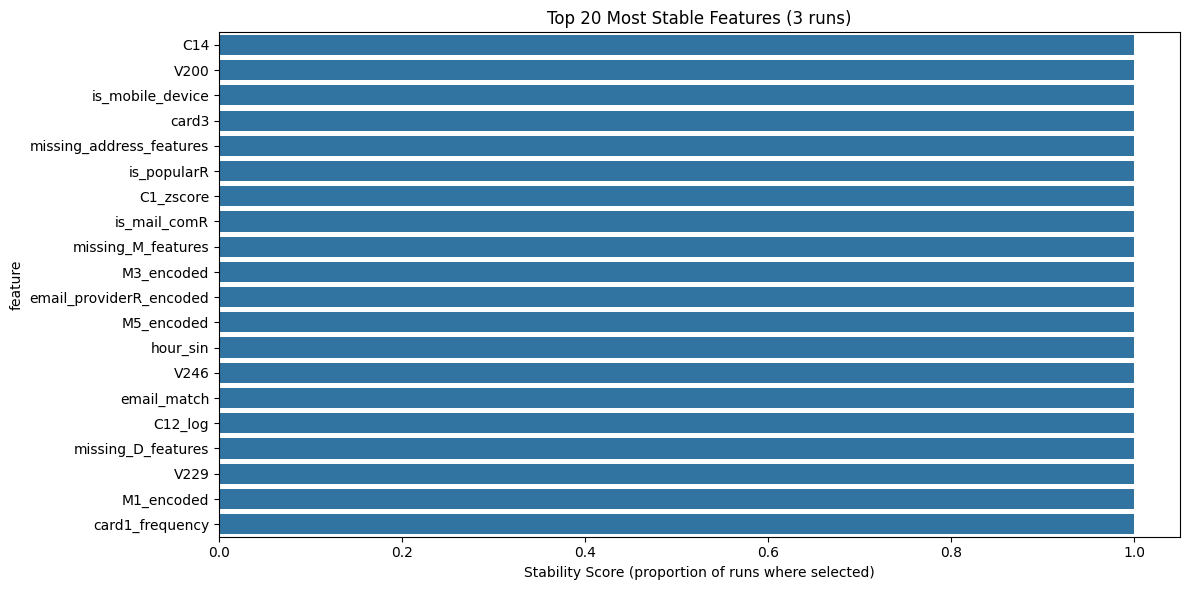

In [5]:

def analyze_feature_stability(X, y, n_runs=5, top_k=100, random_state=42):
    print(f"Running stability analysis with {n_runs} iterations...")
    
    feature_stability = {}
    
    for run in range(n_runs):
        print(f"  Run {run+1}/{n_runs}...")
        current_seed = random_state + run
        top_features_run, _ = enhanced_feature_selection(X, y, top_k=top_k, random_state=current_seed)
        
        for feature in top_features_run:
            if feature not in feature_stability:
                feature_stability[feature] = 0
            feature_stability[feature] += 1
    
    # Convert to DataFrame
    stability_df = pd.DataFrame({
        'feature': list(feature_stability.keys()),
        'stability_score': [score / n_runs for score in feature_stability.values()]
    }).sort_values('stability_score', ascending=False)
    
    print(f"\nFeature Stability Results ({n_runs} runs):")
    print(f"Always selected: {len(stability_df[stability_df['stability_score'] == 1.0])} features")
    print(f"Usually selected (>80%): {len(stability_df[stability_df['stability_score'] >= 0.8])} features")
    
    # Plot stability results
    plt.figure(figsize=(12, 6))
    top_20_stable = stability_df.head(20)
    sns.barplot(x='stability_score', y='feature', data=top_20_stable)
    plt.title(f'Top 20 Most Stable Features ({n_runs} runs)')
    plt.xlabel('Stability Score (proportion of runs where selected)')
    plt.tight_layout()
    plt.show()
    
    return stability_df

# Run stability analysis (optional - can be commented for speed)
stability_df = analyze_feature_stability(X, y, n_runs=3, top_k=100, random_state=42)

## 3. Enhanced Feature Selection Validation


In [6]:

# Keep only selected features
X_selected = X[top_features]
X_test_selected = X_test[[f for f in top_features if f in X_test.columns]]

print(f"After selection - Train: {X_selected.shape}, Test: {X_test_selected.shape}")

After selection - Train: (590540, 100), Test: (506691, 100)


In [7]:
def enhanced_validation(X_original, X_selected, y, cv=3):
    
    from sklearn.model_selection import cross_validate
    from sklearn.metrics import make_scorer, average_precision_score
    
    # Define multiple scoring metrics for fraud detection
    scoring = {
        'auc': 'roc_auc',
        'pr_auc': make_scorer(average_precision_score),  # Important for imbalanced data
        'f1': 'f1'
    }
    
    models = {
        'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, is_unbalance=True),
        'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
        'LogisticRegression': LogisticRegression(random_state=42, class_weight='balanced')
    }
    
    results = {}
    
    for model_name, model in models.items():
        print(f"Validating {model_name}...")
        
        # Original features
        original_scores = cross_validate(model, X_original, y, cv=cv, scoring=scoring, n_jobs=-1)
        # Selected features  
        selected_scores = cross_validate(model, X_selected, y, cv=cv, scoring=scoring, n_jobs=-1)
        
        results[model_name] = {
            'original_auc': original_scores['test_auc'].mean(),
            'selected_auc': selected_scores['test_auc'].mean(),
            'original_pr_auc': original_scores['test_pr_auc'].mean(), 
            'selected_pr_auc': selected_scores['test_pr_auc'].mean(),
            'feature_reduction': f"{(1 - X_selected.shape[1] / X_original.shape[1]) * 100:.1f}%"
        }
    
    # Display results
    print("\n" + "="*80)
    print("ENHANCED FEATURE SELECTION VALIDATION RESULTS")
    print("="*80)
    
    for model_name, scores in results.items():
        auc_improvement = scores['selected_auc'] - scores['original_auc']
        pr_auc_improvement = scores['selected_pr_auc'] - scores['original_pr_auc']
        
        print(f"\n{model_name}:")
        print(f"  Original features ({X_original.shape[1]}): AUC = {scores['original_auc']:.4f}, PR-AUC = {scores['original_pr_auc']:.4f}")
        print(f"  Selected features ({X_selected.shape[1]}): AUC = {scores['selected_auc']:.4f}, PR-AUC = {scores['selected_pr_auc']:.4f}")
        print(f"  Feature reduction: {scores['feature_reduction']}")
        
        if auc_improvement > 0:
            print(f"  ✅ AUC Improvement: +{auc_improvement:.4f}")
        else:
            print(f"  ⚠️  AUC Change: {auc_improvement:.4f}")
            
        if pr_auc_improvement > 0:
            print(f"  ✅ PR-AUC Improvement: +{pr_auc_improvement:.4f}")
        else:
            print(f"  ⚠️  PR-AUC Change: {pr_auc_improvement:.4f}")
    
    return results

# Run enhanced validation
validation_results = enhanced_validation(X, X_selected, y, cv=3)

Validating LightGBM...
Validating RandomForest...
Validating LogisticRegression...

ENHANCED FEATURE SELECTION VALIDATION RESULTS

LightGBM:
  Original features (267): AUC = 0.8545, PR-AUC = 0.0972
  Selected features (100): AUC = 0.8536, PR-AUC = 0.0922
  Feature reduction: 62.5%
  ⚠️  AUC Change: -0.0009
  ⚠️  PR-AUC Change: -0.0050

RandomForest:
  Original features (267): AUC = 0.8343, PR-AUC = 0.2183
  Selected features (100): AUC = 0.8208, PR-AUC = 0.2118
  Feature reduction: 62.5%
  ⚠️  AUC Change: -0.0135
  ⚠️  PR-AUC Change: -0.0065

LogisticRegression:
  Original features (267): AUC = 0.7022, PR-AUC = 0.0570
  Selected features (100): AUC = 0.7088, PR-AUC = 0.0561
  Feature reduction: 62.5%
  ✅ AUC Improvement: +0.0066
  ⚠️  PR-AUC Change: -0.0009


## 4. Feature Importance Visualization (Enhanced)


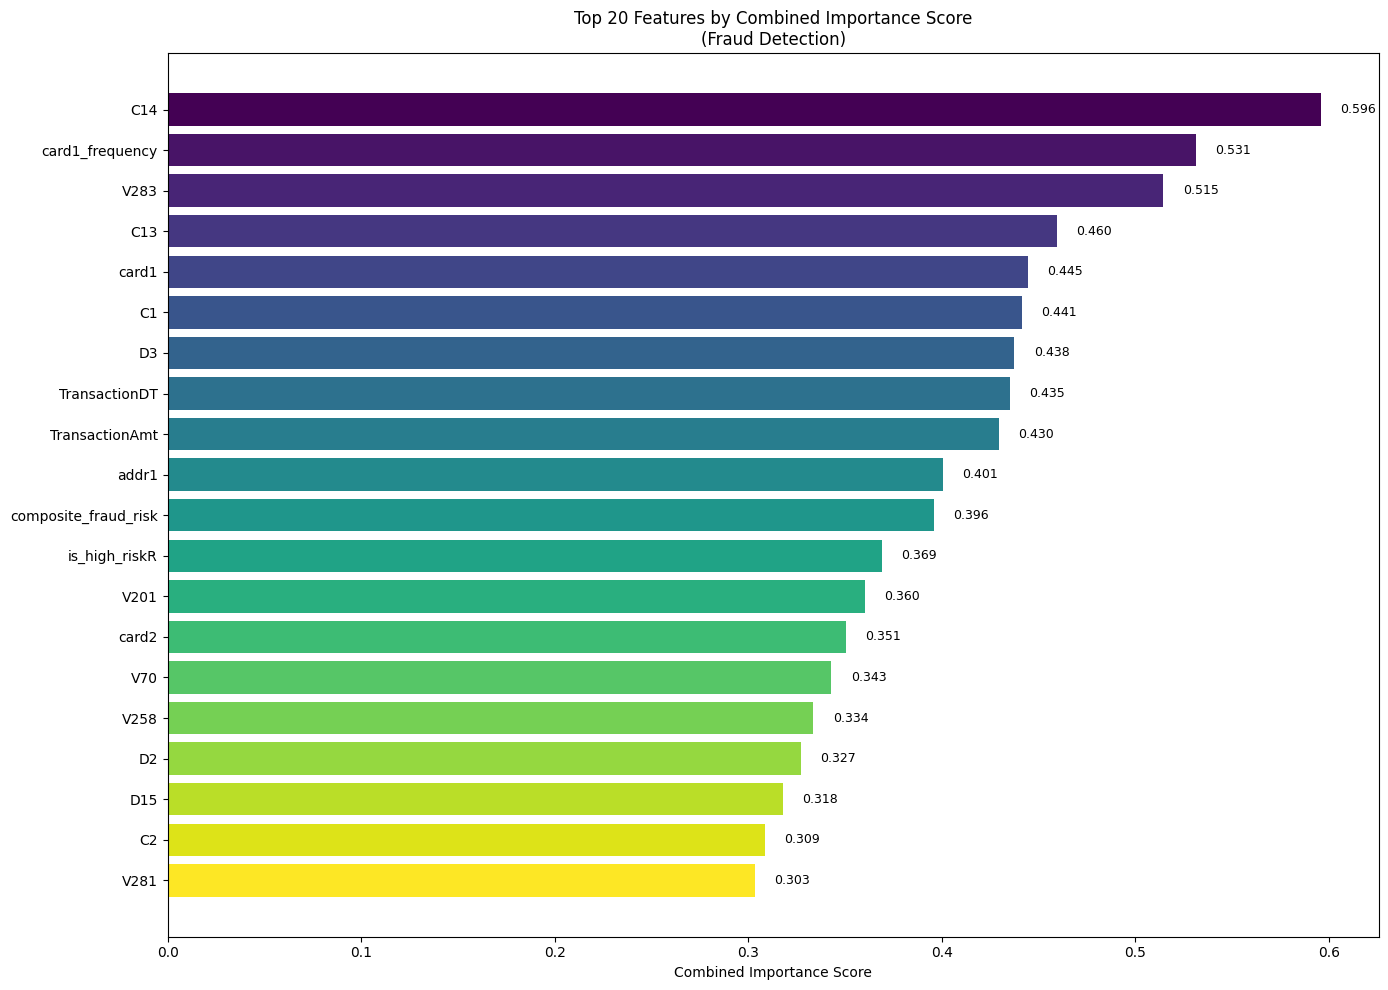

In [8]:

# Plot top features by combined importance
top_20_features = importance_df.nlargest(20, 'combined_score')

plt.figure(figsize=(14, 10))
colors = plt.cm.viridis(np.linspace(0, 1, len(top_20_features)))
bars = plt.barh(range(len(top_20_features)), top_20_features['combined_score'], color=colors)
plt.yticks(range(len(top_20_features)), top_20_features.index)
plt.xlabel('Combined Importance Score')
plt.title('Top 20 Features by Combined Importance Score\n(Fraud Detection)')
plt.gca().invert_yaxis()

# Add value annotations
for i, bar in enumerate(bars):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.3f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

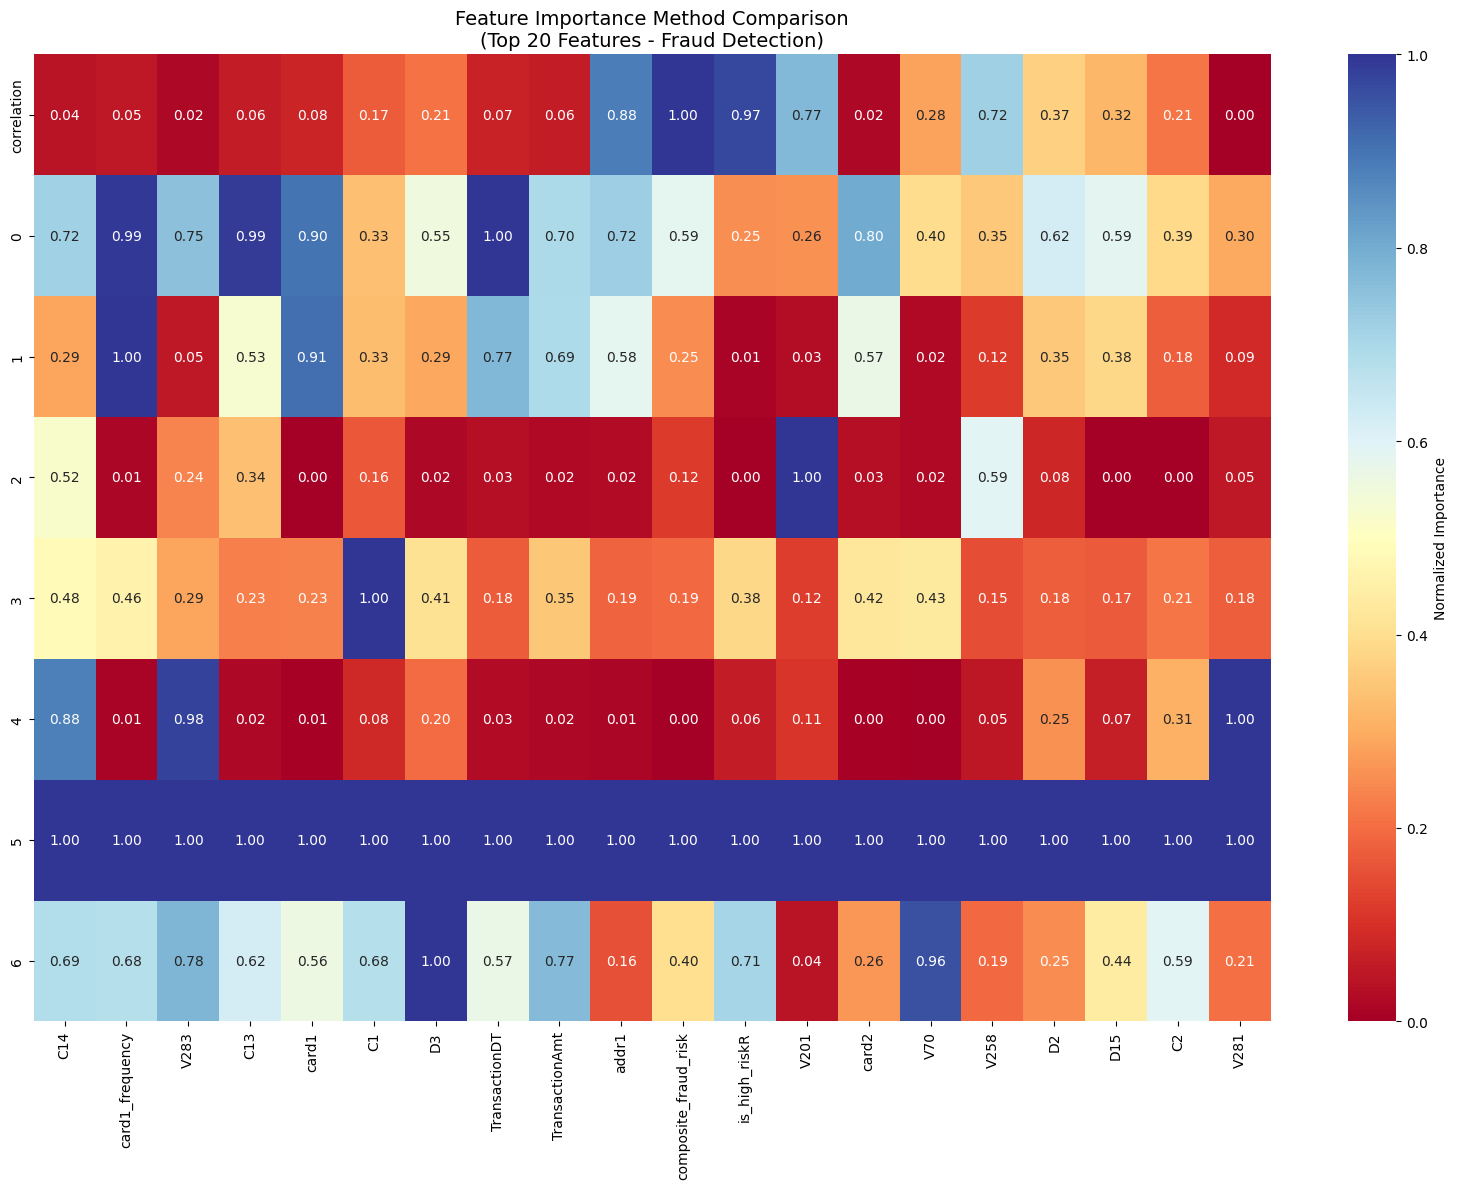

In [9]:
# Method comparison heatmap (enhanced)
plt.figure(figsize=(16, 12))
method_scores = importance_df.loc[top_20_features.index].drop('combined_score', axis=1)

# Normalize for better visualization
method_scores_normalized = method_scores.div(method_scores.max(axis=0), axis=1)

sns.heatmap(method_scores_normalized.T, annot=True, fmt='.2f', cmap='RdYlBu', 
            center=0.5, cbar_kws={'label': 'Normalized Importance'})
plt.title('Feature Importance Method Comparison\n(Top 20 Features - Fraud Detection)', fontsize=14)
plt.tight_layout()
plt.show()


Feature Category Analysis:
Transaction Amount       :   2 features, avg importance = 0.3268
Advanced Features        :   3 features, avg importance = 0.3036
Count Features           :  10 features, avg importance = 0.2816
Card                     :   8 features, avg importance = 0.2766
Other                    :  28 features, avg importance = 0.2263
Product                  :   1 features, avg importance = 0.2025
Identity                 :   5 features, avg importance = 0.1938
V-Features               :  37 features, avg importance = 0.1764
Email                    :   6 features, avg importance = 0.1733
Temporal                 :   3 features, avg importance = 0.1686


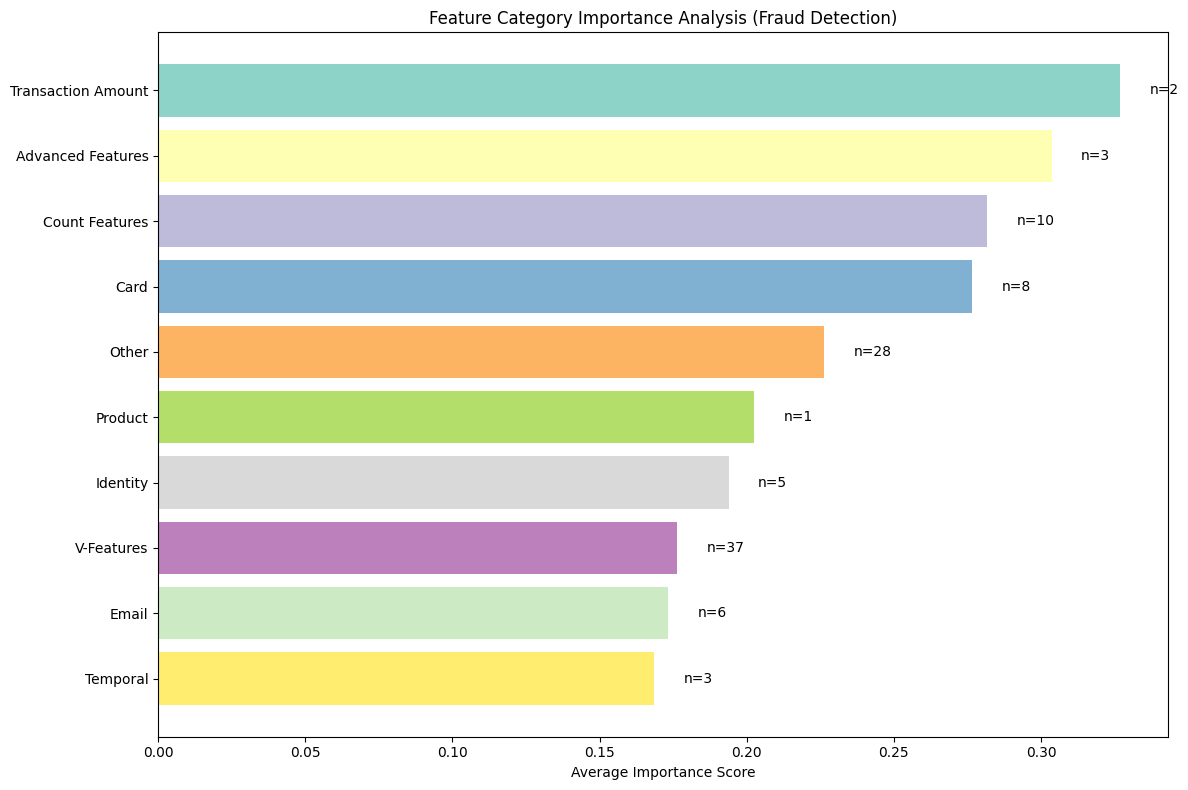

In [11]:

def analyze_feature_categories(features, importance_df):
    
    # Step 1 — create categories WITHOUT "Other"
    feature_categories = {
        'Transaction Amount': [f for f in features if 'amount' in f.lower() or 'transactionamt' in f.lower()],
        'Temporal': [f for f in features if any(x in f.lower() for x in ['hour', 'day', 'weekend', 'night', 'peak'])],
        'Product': [f for f in features if 'product' in f.lower()],
        'Card': [f for f in features if 'card' in f.lower()],
        'Email': [f for f in features if 'email' in f.lower()],
        'Identity': [f for f in features if any(x in f.lower() for x in ['id_', 'os', 'browser', 'device'])],
        'Advanced Features': [f for f in features if any(x in f.lower() for x in ['composite', 'cluster', 'risk', 'interaction'])],
        'V-Features': [f for f in features if f.startswith('V')],
        'Count Features': [f for f in features if f.startswith('C') and len(f) <= 3],
    }
    
    # Step 2 — Flatten all categorized features
    categorized = set([item for sublist in feature_categories.values() for item in sublist])
    
    # Step 3 — Add "Other" category
    feature_categories['Other'] = [f for f in features if f not in categorized]
    
    # Step 4 — Compute importance stats
    category_importance = {}
    for category, cat_features in feature_categories.items():
        if len(cat_features) > 0:
            avg_imp = importance_df.loc[cat_features, 'combined_score'].mean()
            category_importance[category] = {
                'count': len(cat_features),
                'avg_importance': avg_imp,
                'features': cat_features
            }
    
    # Step 5 — Sort categories by importance
    sorted_categories = sorted(
        category_importance.items(),
        key=lambda x: x[1]['avg_importance'],
        reverse=True
    )
    
    # Step 6 — Print results
    print("\nFeature Category Analysis:")
    print("="*50)
    for category, info in sorted_categories:
        print(f"{category:25}: {info['count']:3d} features, avg importance = {info['avg_importance']:.4f}")
    
    # Step 7 — Plot results
    plt.figure(figsize=(12, 8))
    categories = [cat[0] for cat in sorted_categories]
    importances = [cat[1]['avg_importance'] for cat in sorted_categories]
    counts = [cat[1]['count'] for cat in sorted_categories]
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(categories)))
    bars = plt.barh(categories, importances, color=colors)

    # Annotate n=counts
    for bar, count in zip(bars, counts):
        plt.text(
            bar.get_width() + 0.01, 
            bar.get_y() + bar.get_height()/2,
            f"n={count}",
            ha='left',
            va='center',
            fontsize=10
        )
    
    plt.xlabel("Average Importance Score")
    plt.title("Feature Category Importance Analysis (Fraud Detection)")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return category_importance


# Run category analysis
category_analysis = analyze_feature_categories(top_features, importance_df)

## 5. Enhanced Feature Selection with Business Logic


In [12]:

def apply_business_logic_filter(features, importance_df, min_business_importance=0.02):
    # Critical fraud indicators from EDA (must-keep features)
    critical_fraud_indicators = [
        'is_protonmailP', 'is_protonmailR',           # Extreme risk: 40-95% fraud
        'is_single_use_card',                         # High risk: 4.24% fraud  
        'is_high_risk_product',                       # Product C & H: 11.5-5.9% fraud
        'composite_fraud_risk',                       # Our engineered risk score
        'is_amount_outlier',                          # Transaction anomalies
        'is_high_risk_OS', 'is_high_risk_browser',    # Device risk
        'C1_outlier', 'C2_outlier',                   # Count feature anomalies
        'is_fraud_peak_hour'                          # Temporal patterns
    ]
    
    # Filter to only include critical features that exist
    existing_critical = [f for f in critical_fraud_indicators if f in features]
    
    print(f"Critical fraud indicators found: {len(existing_critical)}/{len(critical_fraud_indicators)}")
    
    # Ensure all critical features are included, even if they scored low
    final_features = set(features)  # Start with selected features
    
    # Add any missing critical features
    missing_critical = set(critical_fraud_indicators) - set(features)
    if missing_critical:
        print(f"Adding {len(missing_critical)} critical features that were missed:")
        for feature in missing_critical:
            if feature in importance_df.index:
                print(f"  + {feature} (importance: {importance_df.loc[feature, 'combined_score']:.4f})")
                final_features.add(feature)
    
    # Remove very low importance features (below threshold)
    low_importance_features = []
    for feature in final_features:
        if feature in importance_df.index and importance_df.loc[feature, 'combined_score'] < min_business_importance:
            low_importance_features.append(feature)
    
    # But don't remove critical features even if low importance
    low_importance_features = [f for f in low_importance_features if f not in critical_fraud_indicators]
    
    if low_importance_features:
        print(f"Removing {len(low_importance_features)} very low importance features:")
        for feature in low_importance_features[:5]:  # Show first 5
            print(f"  - {feature} (importance: {importance_df.loc[feature, 'combined_score']:.4f})")
        if len(low_importance_features) > 5:
            print(f"  ... and {len(low_importance_features) - 5} more")
        
        final_features = final_features - set(low_importance_features)
    
    final_features_list = list(final_features)
    
    print(f"\nFinal feature count after business logic: {len(final_features_list)}")
    print(f"Added {len(missing_critical)} critical features")
    print(f"Removed {len(low_importance_features)} low importance features")
    
    return final_features_list

In [13]:
# Apply business logic filter
final_features = apply_business_logic_filter(top_features, importance_df, min_business_importance=0.01)

# Update selected datasets
X_selected_final = X[final_features]
X_test_selected_final = X_test[[f for f in final_features if f in X_test.columns]]

print(f"\nFinal datasets:")
print(f"Train: {X_selected_final.shape}")
print(f"Test: {X_test_selected_final.shape}")

Critical fraud indicators found: 1/11
Adding 10 critical features that were missed:
  + is_single_use_card (importance: 0.0246)
  + is_high_risk_product (importance: 0.0638)
  + is_amount_outlier (importance: 0.0617)
  + is_fraud_peak_hour (importance: 0.0819)
  + is_protonmailR (importance: 0.0561)
  + C2_outlier (importance: 0.0887)
  + is_protonmailP (importance: 0.0391)
  + C1_outlier (importance: 0.0982)

Final feature count after business logic: 108
Added 10 critical features
Removed 0 low importance features

Final datasets:
Train: (590540, 108)
Test: (506691, 108)


## 6. Save Enhanced Selected Features


In [15]:

# Create final datasets with selected features
train_final = pd.DataFrame({
    'TransactionID': train_data['TransactionID'],
    'isFraud': train_data['isFraud']
})
test_final = pd.DataFrame({
    'TransactionID': test_data['TransactionID']
})

# Add selected features
for feature in final_features:
    if feature in X_selected_final.columns:
        train_final[feature] = X_selected_final[feature]
    if feature in X_test_selected_final.columns:
        test_final[feature] = X_test_selected_final[feature]

print(f"Final training set: {train_final.shape}")
print(f"Final test set: {test_final.shape}")

Final training set: (590540, 110)
Final test set: (506691, 109)


In [16]:
# Save selected features
train_final.to_parquet(f"{DATA_FEATURES_PATH}train_features_selected_enhanced.parquet", index=False)
test_final.to_parquet(f"{DATA_FEATURES_PATH}test_features_selected_enhanced.parquet", index=False)

# Save importance analysis with additional metadata
importance_metadata = {
    'selection_method': 'enhanced_multi_method',
    'original_feature_count': X.shape[1],
    'final_feature_count': len(final_features),
    'reduction_percentage': f"{(1 - len(final_features) / X.shape[1]) * 100:.1f}%",
    'critical_features_added': len(set(final_features) - set(top_features)),
    'timestamp': pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
}

# Add metadata to importance_df
importance_df['in_final_selection'] = importance_df.index.isin(final_features)
importance_df['is_critical_feature'] = importance_df.index.isin([
    'is_protonmailP', 'is_protonmailR', 'is_single_use_card', 'is_high_risk_product',
    'composite_fraud_risk', 'is_amount_outlier', 'is_high_risk_OS', 
    'is_high_risk_browser', 'C1_outlier', 'C2_outlier', 'is_fraud_peak_hour'
])

importance_df.to_parquet(f"{DATA_FEATURES_PATH}feature_importance_enhanced.parquet")

In [17]:
# Save metadata separately
metadata_df = pd.DataFrame([importance_metadata])
metadata_df.to_parquet(f"{DATA_FEATURES_PATH}feature_selection_metadata.parquet")

print("Saved enhanced selected features:")
print(f"Train: {DATA_FEATURES_PATH}train_features_selected_enhanced.parquet")
print(f"Test: {DATA_FEATURES_PATH}test_features_selected_enhanced.parquet")
print(f"Importance: {DATA_FEATURES_PATH}feature_importance_enhanced.parquet")
print(f"Metadata: {DATA_FEATURES_PATH}feature_selection_metadata.parquet")

Saved enhanced selected features:
Train: ../data/processed/features/train_features_selected_enhanced.parquet
Test: ../data/processed/features/test_features_selected_enhanced.parquet
Importance: ../data/processed/features/feature_importance_enhanced.parquet
Metadata: ../data/processed/features/feature_selection_metadata.parquet


## 7. Final Enhanced Selection Report


In [19]:

# Calculate statistics
original_count = X.shape[1]
selected_count = len(final_features)
reduction_pct = (1 - selected_count / original_count) * 100

# Get performance from validation
best_auc_improvement = max([results['selected_auc'] - results['original_auc'] for results in validation_results.values()])
best_model = [name for name, results in validation_results.items() 
              if results['selected_auc'] - results['original_auc'] == best_auc_improvement][0]

summary_stats = {
    'Original Features': original_count,
    'Selected Features': selected_count,
    'Reduction': f"{reduction_pct:.1f}%",
    'Final Training Shape': f"{train_final.shape}",
    'Final Test Shape': f"{test_final.shape}",
    'Best Model': best_model,
    'Best AUC Improvement': f"{best_auc_improvement:.4f}",
    'Critical Features Ensured': f"{len([f for f in final_features if 'is_protonmail' in f or 'composite_fraud_risk' in f])}",
}

In [20]:
for key, value in summary_stats.items():
    print(f"  {key:25}: {value}")

  Original Features        : 267
  Selected Features        : 108
  Reduction                : 59.6%
  Final Training Shape     : (590540, 110)
  Final Test Shape         : (506691, 109)
  Best Model               : LogisticRegression
  Best AUC Improvement     : 0.0066
  Critical Features Ensured: 3


In [21]:
category_counts = {}
for category, info in category_analysis.items():
    selected_in_category = len([f for f in info['features'] if f in final_features])
    if selected_in_category > 0:
        category_counts[category] = selected_in_category

# Sort by count
for category, count in sorted(category_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / selected_count) * 100
    print(f"  {category:25}: {count:2d} features ({percentage:.1f}%)")

print(f"\n🔍 CRITICAL FRAUD INDICATORS INCLUDED:")
critical_features = [f for f in final_features if any(x in f for x in [
    'protonmail', 'single_use', 'high_risk_product', 'composite_fraud_risk'
])]

  V-Features               : 37 features (34.3%)
  Other                    : 28 features (25.9%)
  Count Features           : 10 features (9.3%)
  Card                     :  8 features (7.4%)
  Email                    :  6 features (5.6%)
  Identity                 :  5 features (4.6%)
  Temporal                 :  3 features (2.8%)
  Advanced Features        :  3 features (2.8%)
  Transaction Amount       :  2 features (1.9%)
  Product                  :  1 features (0.9%)

🔍 CRITICAL FRAUD INDICATORS INCLUDED:


In [22]:
for feature in critical_features:
    importance = importance_df.loc[feature, 'combined_score'] if feature in importance_df.index else 'N/A'
    print(f"  ✓ {feature:30} (importance: {importance:.4f})")

  ✓ composite_fraud_risk           (importance: 0.3958)
  ✓ is_protonmailP                 (importance: 0.0391)
  ✓ is_single_use_card             (importance: 0.0246)
  ✓ is_high_risk_product           (importance: 0.0638)
  ✓ is_protonmailR                 (importance: 0.0561)
